# Final Simulator Implementation — QSVM Diagnostic Intervention on BreaKHis

This notebook contains the final simulator / analytic statevector-equivalent implementation of the dissertation’s practical diagnostic intervention for breast cancer histopathology classification.

The workflow uses the BreaKHis dataset with patient-wise train/validation/test splitting to reduce leakage. A frozen pretrained ResNet-50 extracts image representations, and a lightweight projection head compresses each image into a scalar parameter $\theta$. The scalar $\theta$ is normalized using training-only statistics and used as input to a one-qubit quantum feature map $H \rightarrow R_y(\theta\pi/2)$. The resulting quantum fidelity kernel is computed analytically, equivalent to noiseless statevector simulation, and passed to a classical SVM solver as a precomputed kernel.

## Final simulator QSVM result

The final QSVM result on the held-out patient-wise test split was:

| Metric | Value |
|---|---:|
| Accuracy | 0.8000 |
| Balanced accuracy | 0.7803 |
| Precision | 0.9051 |
| Recall / sensitivity | 0.8196 |
| Specificity | 0.7409 |
| F1-score | 0.8602 |
| MCC | 0.5196 |
| AUC-ROC | 0.8038 |
| Patient-level recognition rate | 0.7906 |

The confusion matrix was:

$$
\begin{bmatrix}
286 & 100 \\
210 & 954
\end{bmatrix}
$$

## Scalar-$\theta$ SVM comparison

| Model | Accuracy | Balanced accuracy | Precision | Recall | Specificity | F1-score | MCC | AUC-ROC |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Classical SVM (linear) | 0.7735 | 0.7661 | 0.9045 | 0.7809 | 0.7513 | 0.8382 | 0.4820 | 0.8038 |
| Classical SVM (RBF) | 0.7968 | 0.7781 | 0.9047 | 0.8153 | 0.7409 | 0.8577 | 0.5143 | 0.8166 |
| QSVM | 0.8000 | 0.7803 | 0.9051 | 0.8196 | 0.7409 | 0.8602 | 0.5196 | 0.8038 |

The QSVM produced the strongest overall balance among the scalar-$\theta$ SVM variants, with the highest accuracy, balanced accuracy, F1-score, and MCC. The improvement over the classical RBF SVM baseline is modest, and the RBF baseline has the highest AUC-ROC. The result should therefore be interpreted as evidence of feasibility and reproducibility of the proposed compact QSVM workflow, not as evidence of quantum advantage.

IBM Quantum hardware execution is not performed in this notebook. The hardware status is explicitly logged as disabled, and the main result should be interpreted as simulator-equivalent.

## Cell 1 — Environment setup

This cell installs the additional libraries required for the classical feature-extraction and QSVM pipeline. PyTorch is checked instead of reinstalled because Colab usually provides a GPU-compatible build.

In [1]:
# ============================================================
# 1. LOCAL ENVIRONMENT VALIDATION
# ============================================================

import sys
import importlib.util

required_packages = [
    "torch",
    "torchvision",
    "qiskit",
    "qiskit_aer",
    "sklearn",
    "pandas",
    "numpy",
    "matplotlib",
    "PIL",
    "tqdm",
]

missing = []

for package in required_packages:
    if importlib.util.find_spec(package) is None:
        missing.append(package)

print("Python executable:", sys.executable)

if missing:
    raise ModuleNotFoundError(
        "Missing packages in the active environment: "
        + ", ".join(missing)
    )

import torch
import torchvision
import qiskit
import qiskit_aer

print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Qiskit version:", qiskit.__version__)
print("Qiskit Aer version:", qiskit_aer.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA is unavailable. Training will run on CPU and will be slow.")

Python executable: C:\Users\Matheus Teixeira\anaconda3\envs\qml-sim\python.exe
Torch version: 2.11.0+cu130
Torchvision version: 0.26.0+cu130
Qiskit version: 2.4.1
Qiskit Aer version: 0.17.2
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Ti


## Cell 2 — Imports, reproducibility, and device check

This cell imports the required libraries, fixes random seeds, defines JSON-safe serialization, and checks the active compute device.

In [2]:
# ============================================================
# 2. IMPORTS, REPRODUCIBILITY, AND DEVICE CHECK
# ============================================================

import os
import re
import json
import math
import random
import shutil
import zipfile
import platform
import subprocess
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision
from torchvision import transforms
from torchvision.models import (
    resnet18,
    resnet34,
    resnet50,
    ResNet18_Weights,
    ResNet34_Weights,
    ResNet50_Weights,
)

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    classification_report,
)

warnings.filterwarnings("ignore")

SEED = 42

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def to_jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, tuple):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4070 Ti


## Cell 3 — Qiskit sanity check

This cell verifies that Qiskit and Aer are installed correctly by constructing the one-qubit feature-map circuit used later for QSVM resource logging.

In [3]:
# ============================================================
# 3. QISKIT SANITY CHECK
# ============================================================

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

def build_sanity_feature_map(theta_value: float = 0.5):
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    qc.ry(float(theta_value) * np.pi / 2.0, 0)
    qc.measure(0, 0)
    return qc

qc = build_sanity_feature_map(theta_value=0.5)
backend = AerSimulator()
tqc = transpile(qc, backend)

print(qc)
print("Depth:", tqc.depth())
print("Gate counts:", dict(tqc.count_ops()))

     ┌───┐┌─────────┐┌─┐
  q: ┤ H ├┤ Ry(π/4) ├┤M├
     └───┘└─────────┘└╥┘
c: 1/═════════════════╩═
                      0 
Depth: 2
Gate counts: {'u3': 1, 'measure': 1}


## Cell 4 — Use local Windows BreaKHis directory

This cell loads the BreaKHis dataset directly from the local Windows filesystem. It replaces Google Drive mounting and avoids dataset-copy overhead.

In [4]:
# ============================================================
# 4. USE LOCAL WINDOWS BREAKHIS DIRECTORY
# ============================================================

from pathlib import Path

BREAST_ROOT = Path(
    r"C:\Users\Matheus Teixeira\Documents\University\Master\Thesis\Diagnostic Intervention\Dataset\BreaKHis_v1\histology_slides\breast"
)

if not BREAST_ROOT.exists():
    raise FileNotFoundError(
        f"Local image folder not found: {BREAST_ROOT}"
    )

print("Using local image root:")
print(BREAST_ROOT)
print("BREAST_ROOT exists:", BREAST_ROOT.exists())
print("Top-level class folders:", [p.name for p in BREAST_ROOT.iterdir() if p.is_dir()])

Using local image root:
C:\Users\Matheus Teixeira\Documents\University\Master\Thesis\Diagnostic Intervention\Dataset\BreaKHis_v1\histology_slides\breast
BREAST_ROOT exists: True
Top-level class folders: ['benign', 'malignant']


## Cell 5 — Build the BreaKHis metadata table

This cell scans the nested BreaKHis directory, parses each image filename, and builds a metadata table with image path, class label, tumor type, magnification, biopsy procedure, sequence number, and patient/slide identifier.

In [5]:
# ============================================================
# 5. BUILD METADATA TABLE FROM BREAKHIS DIRECTORIES
# ============================================================

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff"}

BENIGN_TYPES = {"A", "F", "PT", "TA"}
MALIGNANT_TYPES = {"DC", "LC", "MC", "PC"}

BREAKHIS_PATTERN = re.compile(
    r"^(?P<biopsy>CNB|SOB)_"
    r"(?P<class_code>B|M)_"
    r"(?P<tumor_type>A|F|PT|TA|DC|LC|MC|PC)"
    r"[_-]"
    r"(?P<year>\d+)-"
    r"(?P<slide_id>[^-]+)-"
    r"(?P<magnification>40|100|200|400)-"
    r"(?P<sequence>.+)$"
)

def normalize_case_id(slide_id: str) -> str:
    """
    Groups slide sections conservatively by removing trailing letters.
    Example: 22549AB -> 22549.
    """
    return re.sub(r"[A-Za-z]+$", "", str(slide_id))

def parse_breakhis_filename(path: Path):
    stem = path.stem

    meta = {
        "filename": path.name,
        "path": str(path),
        "biopsy_procedure": None,
        "tumor_class_code": None,
        "tumor_type": None,
        "year": None,
        "slide_id_raw": None,
        "case_id": None,
        "patient_id": None,
        "magnification": None,
        "sequence": None,
        "parse_ok": False,
    }

    match = BREAKHIS_PATTERN.match(stem)
    if match is None:
        return meta

    gd = match.groupdict()

    meta["biopsy_procedure"] = gd["biopsy"]
    meta["tumor_class_code"] = gd["class_code"]
    meta["tumor_type"] = gd["tumor_type"]
    meta["year"] = gd["year"]
    meta["slide_id_raw"] = gd["slide_id"]

    # Use the raw slide/patient identifier. Do not remove trailing letters.
    meta["case_id"] = gd["slide_id"]
    meta["patient_id"] = f"{gd['year']}-{gd['slide_id']}"

    meta["magnification"] = int(gd["magnification"])
    meta["sequence"] = gd["sequence"]
    meta["parse_ok"] = True

    return meta

def build_metadata(breast_root: Path) -> pd.DataFrame:
    rows = []

    for img_path in breast_root.rglob("*"):
        if not (img_path.is_file() and img_path.suffix.lower() in IMAGE_EXTS):
            continue

        lower_parts = [p.lower() for p in img_path.parts]

        label_from_dir = None
        if "benign" in lower_parts:
            label_from_dir = 0
        elif "malignant" in lower_parts:
            label_from_dir = 1

        meta = parse_breakhis_filename(img_path)

        if meta["tumor_class_code"] == "B":
            label = 0
        elif meta["tumor_class_code"] == "M":
            label = 1
        else:
            label = label_from_dir

        meta["label"] = label
        meta["label_name"] = "malignant" if label == 1 else "benign"

        rows.append(meta)

    df_meta = pd.DataFrame(rows)

    if len(df_meta) == 0:
        raise RuntimeError(f"No images found under: {breast_root}")

    failed = df_meta[~df_meta["parse_ok"]].copy()
    if len(failed) > 0:
        print("Warning: some filenames were not parsed.")
        display(failed[["filename", "path"]].head(20))

    df_meta = df_meta[df_meta["parse_ok"]].copy()
    df_meta = df_meta.dropna(subset=["label", "patient_id", "magnification"]).copy()

    df_meta["label"] = df_meta["label"].astype(int)
    df_meta["magnification"] = df_meta["magnification"].astype(int)

    return df_meta.reset_index(drop=True)

df = build_metadata(BREAST_ROOT)

print("Total parsed images:", len(df))
print("Unique patient/case IDs:", df["patient_id"].nunique())

display(df.head())

print("\nClass counts:")
display(df["label_name"].value_counts())

print("\nMagnification x class:")
display(pd.crosstab(df["magnification"], df["label_name"]))

print("\nTumor type x class:")
display(pd.crosstab(df["tumor_type"], df["label_name"]))

Total parsed images: 7909
Unique patient/case IDs: 81


,filename,path,biopsy_procedure,tumor_class_code,tumor_type,year,slide_id_raw,case_id,patient_id,magnification,sequence,parse_ok,label,label_name
0,SOB_B_A-14-22549AB-100-001.png,C:\Users\Matheus Teixeira\Documents\University...,SOB,B,A,14,22549AB,22549AB,14-22549AB,100,001,True,0,benign
1,SOB_B_A-14-22549AB-100-002.png,C:\Users\Matheus Teixeira\Documents\University...,SOB,B,A,14,22549AB,22549AB,14-22549AB,100,002,True,0,benign
2,SOB_B_A-14-22549AB-100-003.png,C:\Users\Matheus Teixeira\Documents\University...,SOB,B,A,14,22549AB,22549AB,14-22549AB,100,003,True,0,benign
3,SOB_B_A-14-22549AB-100-004.png,C:\Users\Matheus Teixeira\Documents\University...,SOB,B,A,14,22549AB,22549AB,14-22549AB,100,004,True,0,benign
4,SOB_B_A-14-22549AB-100-005.png,C:\Users\Matheus Teixeira\Documents\University...,SOB,B,A,14,22549AB,22549AB,14-22549AB,100,005,True,0,benign



Class counts:


label_name
malignant    5429
benign       2480
Name: count, dtype: int64


Magnification x class:


label_name,benign,malignant
magnification,,
40,625,1370
100,644,1437
200,623,1390
400,588,1232



Tumor type x class:


label_name,benign,malignant
tumor_type,,
A,444,0
DC,0,3451
F,1014,0
LC,0,626
MC,0,792
PC,0,560
PT,453,0
TA,569,0


In [6]:
# ============================================================
# PATIENT ID AUDIT
# ============================================================

df["patient_id_raw"] = df["year"].astype(str) + "-" + df["slide_id_raw"].astype(str)
df["patient_id_normalized"] = df["year"].astype(str) + "-" + df["case_id"].astype(str)

print("Unique raw patient/slide IDs:", df["patient_id_raw"].nunique())
print("Unique normalized patient/case IDs:", df["patient_id_normalized"].nunique())

print("\nRaw ID label conflicts:")
display(
    df.groupby("patient_id_raw")["label"]
      .nunique()
      .value_counts()
)

print("\nNormalized ID label conflicts:")
display(
    df.groupby("patient_id_normalized")["label"]
      .nunique()
      .value_counts()
)

print("\nExamples where normalization merges multiple raw IDs:")
merge_audit = (
    df.groupby("patient_id_normalized")["patient_id_raw"]
      .nunique()
      .reset_index(name="n_raw_ids")
      .query("n_raw_ids > 1")
      .sort_values("n_raw_ids", ascending=False)
)

display(merge_audit.head(20))

Unique raw patient/slide IDs: 81
Unique normalized patient/case IDs: 81

Raw ID label conflicts:


label
1    81
Name: count, dtype: int64


Normalized ID label conflicts:


label
1    81
Name: count, dtype: int64


Examples where normalization merges multiple raw IDs:


,patient_id_normalized,n_raw_ids


## Cell 6 — Validate metadata integrity

This cell checks whether the parsed metadata matches the expected BreaKHis structure before training. It reports image counts, class counts, magnification counts, subtype counts, and patient/case identifiers.

In [7]:
# ============================================================
# 6. DATASET VALIDATION CHECKS
# ============================================================

expected_magnifications = {40, 100, 200, 400}
found_magnifications = set(df["magnification"].unique())

assert found_magnifications.issubset(expected_magnifications), found_magnifications
assert df["label"].isin([0, 1]).all()
assert df["path"].is_unique, "Duplicate image paths found."

print("Images parsed:", len(df))
print("Expected BreaKHis images: 7909")

if len(df) != 7909:
    print("Warning: parsed image count differs from 7909. Inspect dataset archive and filename parser.")

print("\nPatient/case IDs parsed:", df["patient_id"].nunique())
print("Expected patients in BreaKHis: 82")

if df["patient_id"].nunique() != 82:
    print("Warning: patient/case ID count differs from 82.")
    print("This may happen if slide sections are grouped conservatively. Inspect patient_id parsing.")

print("\nMagnifications found:", sorted(found_magnifications))

print("\nImage counts by magnification and class:")
display(
    df.groupby(["magnification", "label_name"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

print("\nImage counts by tumor subtype and class:")
display(
    df.groupby(["tumor_type", "label_name"])
      .size()
      .unstack(fill_value=0)
)

patient_label_counts = df.groupby("patient_id")["label"].nunique()

if (patient_label_counts > 1).any():
    print("Warning: some patient/case IDs contain both labels. Inspect parser.")
    display(patient_label_counts[patient_label_counts > 1].head(20))
else:
    print("All patient/case IDs are single-label under the current parser.")

Images parsed: 7909
Expected BreaKHis images: 7909

Patient/case IDs parsed: 81
Expected patients in BreaKHis: 82
This may happen if slide sections are grouped conservatively. Inspect patient_id parsing.

Magnifications found: [np.int64(40), np.int64(100), np.int64(200), np.int64(400)]

Image counts by magnification and class:


label_name,benign,malignant
magnification,,
40,625,1370
100,644,1437
200,623,1390
400,588,1232



Image counts by tumor subtype and class:


label_name,benign,malignant
tumor_type,,
A,444,0
DC,0,3451
F,1014,0
LC,0,626
MC,0,792
PC,0,560
PT,453,0
TA,569,0


All patient/case IDs are single-label under the current parser.


In [8]:
# ============================================================
# PATIENT/CASE COUNT AUDIT BY SUBTYPE
# ============================================================

patient_subtype_counts = (
    df.drop_duplicates("patient_id")
      .groupby(["tumor_type", "label_name"])
      .size()
      .reset_index(name="n_patient_ids")
      .sort_values(["label_name", "tumor_type"])
)

print("Patient/case counts by tumor subtype:")
display(patient_subtype_counts)

image_subtype_counts = (
    df.groupby(["tumor_type", "label_name"])
      .size()
      .reset_index(name="n_images")
      .sort_values(["label_name", "tumor_type"])
)

print("Image counts by tumor subtype:")
display(image_subtype_counts)

print("Total patient/case IDs:", df["patient_id"].nunique())
print("Total images:", len(df))

Patient/case counts by tumor subtype:


,tumor_type,label_name,n_patient_ids
0,A,benign,4
2,F,benign,10
6,PT,benign,3
7,TA,benign,7
1,DC,malignant,38
3,LC,malignant,4
4,MC,malignant,9
5,PC,malignant,6


Image counts by tumor subtype:


,tumor_type,label_name,n_images
0,A,benign,444
2,F,benign,1014
6,PT,benign,453
7,TA,benign,569
1,DC,malignant,3451
3,LC,malignant,626
4,MC,malignant,792
5,PC,malignant,560


Total patient/case IDs: 81
Total images: 7909


## Cell 7 — Patient-wise stratified split

This cell creates train, validation, and test splits at the patient/case level. Images from the same patient/case cannot appear in more than one split, which prevents leakage from patient-specific morphology or acquisition artifacts.

In [9]:
# ============================================================
# 7. PATIENT-WISE STRATIFIED SPLIT
# ============================================================

EXPERIMENT_MAGNIFICATION = "all"   # Use "all" for the thesis main experiment, or 40/100/200/400 for ablations.

TRAIN_FRAC = 0.60
VAL_FRAC = 0.20
TEST_FRAC = 0.20

assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-9

if EXPERIMENT_MAGNIFICATION == "all":
    df_exp_base = df.copy()
    experiment_name = "all_magnifications"
else:
    df_exp_base = df[df["magnification"] == int(EXPERIMENT_MAGNIFICATION)].copy()
    experiment_name = f"{EXPERIMENT_MAGNIFICATION}x"

df_exp_base = df_exp_base.reset_index(drop=True)

print("Experiment:", experiment_name)
print("Images:", len(df_exp_base))
print("Patient/case IDs:", df_exp_base["patient_id"].nunique())
display(pd.crosstab(df_exp_base["magnification"], df_exp_base["label_name"]))

PROJECT_ROOT = Path(
    r"C:\Users\Matheus Teixeira\Documents\University\Master\Thesis\Diagnostic Intervention"
)

OUT_DIR = PROJECT_ROOT / "outputs" / f"thesis_qsvm_breakhis_{experiment_name}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def patient_level_table(df_in: pd.DataFrame) -> pd.DataFrame:
    grouped = df_in.groupby("patient_id")

    label_nunique = grouped["label"].nunique()
    if (label_nunique > 1).any():
        bad = label_nunique[label_nunique > 1].index.tolist()[:10]
        raise ValueError(f"Patient/case IDs with multiple labels detected: {bad}")

    patients = grouped.agg(
        label=("label", "first"),
        label_name=("label_name", "first"),
        n_images=("path", "count"),
    ).reset_index()

    return patients

def make_patientwise_split(df_in: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    patients = patient_level_table(df_in)

    patient_idx = np.arange(len(patients))
    y_patient = patients["label"].values

    splitter1 = StratifiedShuffleSplit(
        n_splits=1,
        train_size=TRAIN_FRAC,
        random_state=seed,
    )

    train_idx, temp_idx = next(splitter1.split(patient_idx, y_patient))

    train_patients = patients.iloc[train_idx].copy()
    temp_patients = patients.iloc[temp_idx].copy()

    relative_val_frac = VAL_FRAC / (VAL_FRAC + TEST_FRAC)

    splitter2 = StratifiedShuffleSplit(
        n_splits=1,
        train_size=relative_val_frac,
        random_state=seed,
    )

    temp_idx_array = np.arange(len(temp_patients))
    y_temp = temp_patients["label"].values

    val_rel_idx, test_rel_idx = next(splitter2.split(temp_idx_array, y_temp))

    val_patients = temp_patients.iloc[val_rel_idx].copy()
    test_patients = temp_patients.iloc[test_rel_idx].copy()

    split_map = {}

    for patient_id in train_patients["patient_id"]:
        split_map[patient_id] = "train"

    for patient_id in val_patients["patient_id"]:
        split_map[patient_id] = "val"

    for patient_id in test_patients["patient_id"]:
        split_map[patient_id] = "test"

    out = df_in.copy()
    out["split"] = out["patient_id"].map(split_map)

    assert out["split"].notna().all()

    split_patients = {
        split: set(out[out["split"] == split]["patient_id"])
        for split in ["train", "val", "test"]
    }

    assert split_patients["train"].isdisjoint(split_patients["val"])
    assert split_patients["train"].isdisjoint(split_patients["test"])
    assert split_patients["val"].isdisjoint(split_patients["test"])

    return out.reset_index(drop=True)

df_exp = make_patientwise_split(df_exp_base, SEED)

print("Image-level split counts:")
display(pd.crosstab(df_exp["split"], df_exp["label_name"]))

print("Patient/case-level split counts:")
display(
    df_exp.drop_duplicates("patient_id")
          .groupby(["split", "label_name"])
          .size()
          .unstack(fill_value=0)
)

print("Magnification distribution by split:")
display(pd.crosstab(df_exp["split"], df_exp["magnification"]))

df_exp.to_csv(OUT_DIR / "metadata_split.csv", index=False)
print("Saved:", OUT_DIR / "metadata_split.csv")

Experiment: all_magnifications
Images: 7909
Patient/case IDs: 81


label_name,benign,malignant
magnification,,
40,625,1370
100,644,1437
200,623,1390
400,588,1232


Image-level split counts:


label_name,benign,malignant
split,,
test,386,1164
train,1552,3192
val,542,1073


Patient/case-level split counts:


label_name,benign,malignant
split,,
test,5,12
train,14,34
val,5,11


Magnification distribution by split:


magnification,40,100,200,400
split,,,,
test,391,406,386,367
train,1208,1237,1211,1088
val,396,438,416,365


Saved: C:\Users\Matheus Teixeira\Documents\University\Master\Thesis\Diagnostic Intervention\outputs\thesis_qsvm_breakhis_all_magnifications\metadata_split.csv


## Cell 8 — Dataset class, image transforms, and deterministic embedding loader

This cell defines the PyTorch dataset and preprocessing pipeline. Training uses histology-safe augmentation, while validation, test, and embedding extraction use deterministic transforms.

In [10]:
# ============================================================
# 8. DATASET CLASS, TRANSFORMS, AND LOADERS
# ============================================================

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10,
        saturation=0.05,
        hue=0.02,
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class BreakHisDataset(Dataset):
    def __init__(self, df_in: pd.DataFrame, transform=None):
        self.df = df_in.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["path"]).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = torch.tensor(row["label"], dtype=torch.long)

        meta = {
            "patient_id": row["patient_id"],
            "path": row["path"],
            "magnification": int(row["magnification"]),
            "tumor_type": row["tumor_type"],
            "filename": row["filename"],
        }

        return image, label, meta

train_df = df_exp[df_exp["split"] == "train"].reset_index(drop=True)
val_df = df_exp[df_exp["split"] == "val"].reset_index(drop=True)
test_df = df_exp[df_exp["split"] == "test"].reset_index(drop=True)

train_ds = BreakHisDataset(train_df, transform=train_tfms)
train_eval_ds = BreakHisDataset(train_df, transform=eval_tfms)
val_ds = BreakHisDataset(val_df, transform=eval_tfms)
test_ds = BreakHisDataset(test_df, transform=eval_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

train_eval_loader = DataLoader(
    train_eval_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

images, labels, metas = next(iter(train_loader))

print("Train images:", len(train_ds))
print("Validation images:", len(val_ds))
print("Test images:", len(test_ds))
print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Train images: 4744
Validation images: 1615
Test images: 1550
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


## Cell 9 — Class imbalance handling

This cell computes class weights from the training split only. These weights are used while training the scalar $\theta$ extractor and do not use validation or test information.

In [11]:
# ============================================================
# 9. CLASS IMBALANCE HANDLING
# ============================================================

classes = np.array([0, 1])

class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values,
)

class_weights = torch.tensor(
    class_weights_np,
    dtype=torch.float32,
).to(DEVICE)

print("Class weights [benign, malignant]:", class_weights_np)

USE_WEIGHTED_SAMPLER = False

if USE_WEIGHTED_SAMPLER:
    counts = train_df["label"].value_counts().to_dict()

    sample_weights = train_df["label"].map(
        lambda label: 1.0 / counts[label]
    ).values

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    print("Using WeightedRandomSampler for training.")
else:
    print("Using weighted loss only.")

Class weights [benign, malignant]: [1.52835052 0.74310777]
Using weighted loss only.


## Cell 10 — Scalar $\theta$ feature extractor

This cell defines the classical feature-compression model used before QSVM. A pretrained ResNet extracts image features, and a lightweight linear–ReLU–linear projection head compresses each image into a scalar $\theta$. The auxiliary classifier is used only to train $\theta$; the final classifier is the SVM/QSVM.

In [12]:
# ============================================================
# 10. SCALAR THETA FEATURE EXTRACTOR
# ============================================================

class ThetaExtractor(nn.Module):
    def __init__(self, backbone_name="resnet50", pretrained=True, freeze_backbone=False):
        super().__init__()

        if backbone_name == "resnet18":
            weights = ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
            base = resnet18(weights=weights)
            in_features = base.fc.in_features

        elif backbone_name == "resnet34":
            weights = ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
            base = resnet34(weights=weights)
            in_features = base.fc.in_features

        elif backbone_name == "resnet50":
            weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
            base = resnet50(weights=weights)
            in_features = base.fc.in_features

        else:
            raise ValueError(f"Unsupported backbone: {backbone_name}")

        base.fc = nn.Identity()
        self.backbone = base

        if freeze_backbone:
            for parameter in self.backbone.parameters():
                parameter.requires_grad = False

        self.theta_projector = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.40),
            nn.Linear(128, 1),
        )
        self.aux_classifier = nn.Linear(1, 2)

    def forward(self, x, return_theta=False):
        features = self.backbone(x)
        theta = self.theta_projector(features)
        logits = self.aux_classifier(theta)

        if return_theta:
            return logits, theta

        return logits

BACKBONE = "resnet50"
FREEZE_BACKBONE = True

theta_model = ThetaExtractor(
    backbone_name=BACKBONE,
    pretrained=True,
    freeze_backbone=FREEZE_BACKBONE,
).to(DEVICE)

x_dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

with torch.no_grad():
    logits_dummy, theta_dummy = theta_model(x_dummy, return_theta=True)

print("Logits shape:", logits_dummy.shape)
print("Theta shape:", theta_dummy.shape)

Logits shape: torch.Size([2, 2])
Theta shape: torch.Size([2, 1])


## Cell 11 — Training utilities for scalar $\theta$

This cell defines reusable functions for training the $\theta$ extractor and computing diagnostic metrics. These metrics monitor whether the scalar representation is class-informative before SVM/QSVM training.

In [13]:
# ============================================================
# 11. TRAINING UTILITIES FOR THETA EXTRACTOR
# ============================================================

def compute_metrics(y_true, y_pred, y_score=None):
    metrics = {}

    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
    metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
    metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
    metrics["mcc"] = matthews_corrcoef(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    metrics["specificity"] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    metrics["balanced_accuracy"] = 0.5 * (metrics["recall"] + metrics["specificity"])

    metrics["tn"] = int(tn)
    metrics["fp"] = int(fp)
    metrics["fn"] = int(fn)
    metrics["tp"] = int(tp)

    if y_score is not None and len(np.unique(y_true)) == 2:
        metrics["auc_roc"] = roc_auc_score(y_true, y_score)
    else:
        metrics["auc_roc"] = np.nan

    return metrics


def print_metrics(prefix, metrics):
    keys = [
        "loss",
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "specificity",
        "f1",
        "mcc",
        "auc_roc",
    ]

    text = prefix + " | " + " | ".join(
        f"{key}: {metrics[key]:.4f}"
        for key in keys
        if key in metrics
    )

    print(text)


def run_theta_epoch(model, loader, criterion, optimizer=None, scaler=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    y_true = []
    y_pred = []
    y_score = []

    for images, labels, meta in tqdm(loader, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(is_train):
            if scaler is not None and is_train:
                with torch.cuda.amp.autocast():
                    logits = model(images)
                    loss = criterion(logits, labels)

                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            else:
                logits = model(images)
                loss = criterion(logits, labels)

                if is_train:
                    optimizer.zero_grad(set_to_none=True)
                    loss.backward()
                    optimizer.step()

        probs = torch.softmax(logits.detach(), dim=1)[:, 1]
        preds = torch.argmax(logits.detach(), dim=1)

        total_loss += loss.item() * images.size(0)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_score.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)

    metrics = compute_metrics(
        np.asarray(y_true),
        np.asarray(y_pred),
        np.asarray(y_score),
    )

    metrics["loss"] = avg_loss

    return metrics

## Cell 12 — Train the classical $\theta$ extractor

This cell trains the ResNet projection model that produces scalar $\theta$. The auxiliary classifier is used only to make the scalar representation class-informative during supervised feature-compression training. It is discarded after this stage; final classification is performed later by classical SVM and QSVM.

In [14]:
# ============================================================
# 12. TRAIN THETA EXTRACTOR
# ============================================================

EPOCHS = 20
LR = 3e-5
USE_AMP = True

theta_model = ThetaExtractor(
    backbone_name=BACKBONE,
    pretrained=True,
    freeze_backbone=FREEZE_BACKBONE,
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    theta_model.parameters(),
    lr=LR,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
)

amp_scaler = torch.cuda.amp.GradScaler(
    enabled=(USE_AMP and DEVICE.type == "cuda")
)

best_val_f1 = -np.inf
theta_history = []

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_metrics = run_theta_epoch(
        theta_model,
        train_loader,
        criterion,
        optimizer=optimizer,
        scaler=amp_scaler,
    )

    val_metrics = run_theta_epoch(
        theta_model,
        val_loader,
        criterion,
        optimizer=None,
    )

    scheduler.step()

    print_metrics("Train", train_metrics)
    print_metrics("Val  ", val_metrics)

    row = {"epoch": epoch}
    row.update({f"train_{key}": value for key, value in train_metrics.items()})
    row.update({f"val_{key}": value for key, value in val_metrics.items()})
    theta_history.append(row)

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]

        checkpoint = {
            "model_state_dict": theta_model.state_dict(),
            "backbone": BACKBONE,
            "freeze_backbone": FREEZE_BACKBONE,
            "experiment_magnification": EXPERIMENT_MAGNIFICATION,
            "seed": SEED,
            "img_size": IMG_SIZE,
            "class_weights": class_weights_np.tolist(),
        }

        torch.save(checkpoint, OUT_DIR / "best_theta_extractor.pt")
        print("Saved best theta extractor.")

theta_history_df = pd.DataFrame(theta_history)
theta_history_df.to_csv(OUT_DIR / "theta_extractor_training_history.csv", index=False)

display(theta_history_df.tail())


Epoch 1/20


  0%|          | 0/149 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

Train | loss: 0.7190 | accuracy: 0.3272 | balanced_accuracy: 0.5000 | precision: 0.0000 | recall: 0.0000 | specificity: 1.0000 | f1: 0.0000 | mcc: 0.0000 | auc_roc: 0.5372
Val   | loss: 0.7594 | accuracy: 0.3356 | balanced_accuracy: 0.5000 | precision: 0.0000 | recall: 0.0000 | specificity: 1.0000 | f1: 0.0000 | mcc: 0.0000 | auc_roc: 0.5833
Saved best theta extractor.

Epoch 2/20


  0%|          | 0/149 [00:00<?, ?it/s]

...

Train | loss: 0.5246 | accuracy: 0.7797 | balanced_accuracy: 0.7767 | precision: 0.8744 | recall: 0.7854 | specificity: 0.7680 | f1: 0.8275 | mcc: 0.5310 | auc_roc: 0.8603
Val   | loss: 0.5956 | accuracy: 0.6960 | balanced_accuracy: 0.7402 | precision: 0.9053 | recall: 0.6058 | specificity: 0.8745 | f1: 0.7259 | mcc: 0.4564 | auc_roc: 0.8294

Epoch 20/20


  0%|          | 0/149 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

Train | loss: 0.5249 | accuracy: 0.7850 | balanced_accuracy: 0.7806 | precision: 0.8755 | recall: 0.7932 | specificity: 0.7680 | f1: 0.8323 | mcc: 0.5398 | auc_roc: 0.8603
Val   | loss: 0.5871 | accuracy: 0.7139 | balanced_accuracy: 0.7514 | precision: 0.9036 | recall: 0.6375 | specificity: 0.8653 | f1: 0.7475 | mcc: 0.4758 | auc_roc: 0.8308


,epoch,train_accuracy,train_precision,train_recall,train_f1,train_mcc,train_specificity,train_balanced_accuracy,train_tn,train_fp,...,val_f1,val_mcc,val_specificity,val_balanced_accuracy,val_tn,val_fp,val_fn,val_tp,val_auc_roc,val_loss
15,16,0.788997,0.878411,0.796679,0.835551,0.548232,0.773196,0.784938,1200,352,...,0.734581,0.456093,0.859779,0.740700,466,76,406,667,0.828602,0.590640
16,17,0.773820,0.871103,0.779135,0.822557,0.519488,0.762887,0.771011,1184,368,...,0.736610,0.465073,0.869004,0.745313,471,71,406,667,0.831739,0.589060
17,18,0.786046,0.879136,0.790727,0.832591,0.544359,0.776418,0.783572,1205,347,...,0.734037,0.467307,0.876384,0.746207,475,67,412,661,0.829512,0.590002
18,19,0.779722,0.874433,0.785401,0.827529,0.531011,0.768041,0.776721,1192,360,...,0.725851,0.456425,0.874539,0.740158,474,68,423,650,0.829369,0.595578
19,20,0.784992,0.875519,0.793233,0.832347,0.539800,0.768041,0.780637,1192,360,...,0.747541,0.475757,0.865314,0.751389,469,73,389,684,0.830786,0.587096


## Cell 12B — Visualize θ extractor training

This cell plots loss, F1-score, and AUC-ROC for the train and validation splits. These curves are used to inspect convergence and overfitting during scalar $\theta$ extractor training.

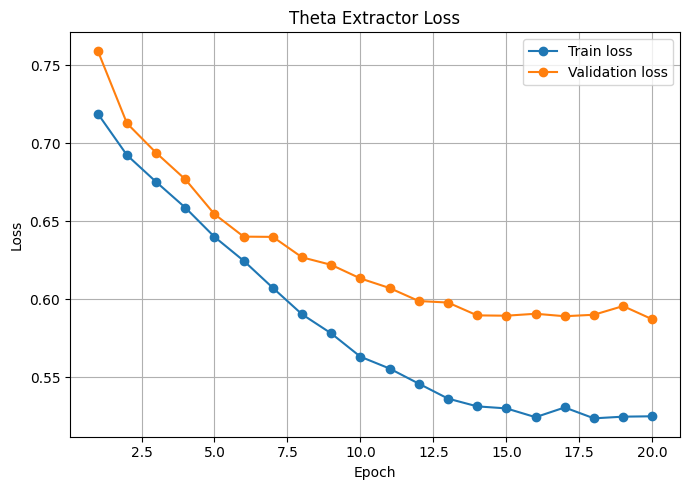

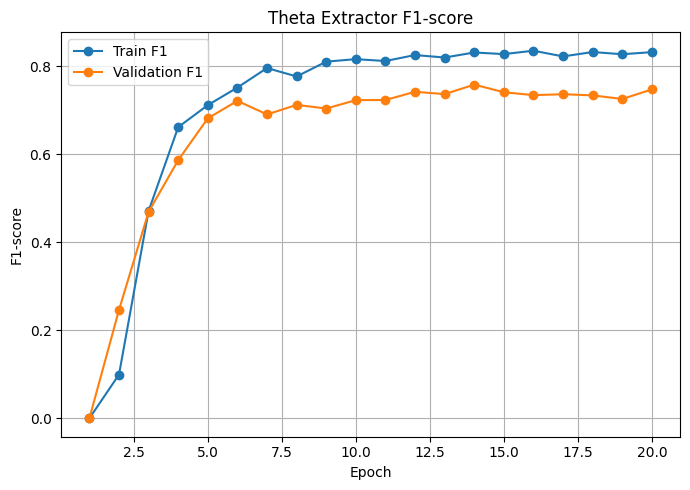

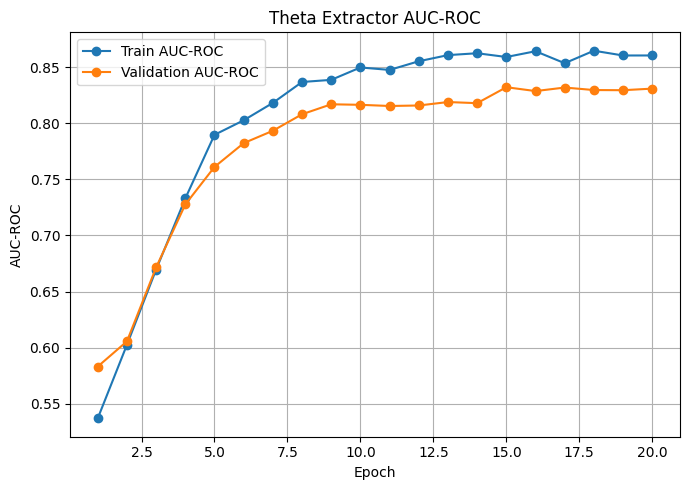

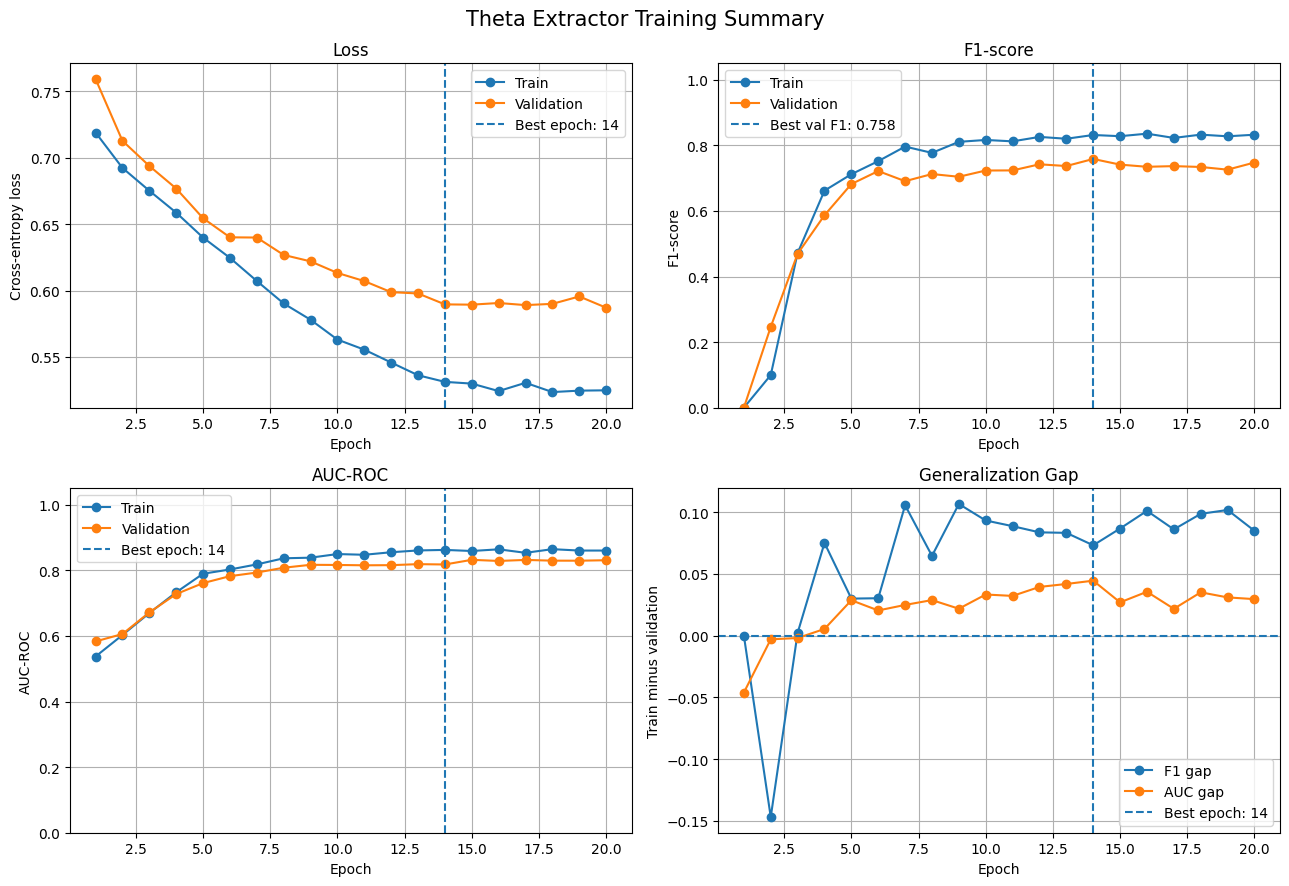

Best validation epoch: 14
Best validation F1-score: 0.7584


In [15]:
# ============================================================
# 12B. VISUALIZATION: THETA EXTRACTOR TRAINING CURVES
# ============================================================

history = theta_history_df.copy()

plt.figure(figsize=(7, 5))
plt.plot(history["epoch"], history["train_loss"], marker="o", label="Train loss")
plt.plot(history["epoch"], history["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Theta Extractor Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "theta_extractor_loss.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history["epoch"], history["train_f1"], marker="o", label="Train F1")
plt.plot(history["epoch"], history["val_f1"], marker="o", label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("Theta Extractor F1-score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "theta_extractor_f1.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history["epoch"], history["train_auc_roc"], marker="o", label="Train AUC-ROC")
plt.plot(history["epoch"], history["val_auc_roc"], marker="o", label="Validation AUC-ROC")
plt.xlabel("Epoch")
plt.ylabel("AUC-ROC")
plt.title("Theta Extractor AUC-ROC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "theta_extractor_auc_roc.png", dpi=300)
plt.show()

# ============================================================
# 12B. VISUALIZATION: THETA EXTRACTOR TRAINING DASHBOARD
# ============================================================

history = theta_history_df.copy()

best_epoch_idx = history["val_f1"].idxmax()
best_epoch = int(history.loc[best_epoch_idx, "epoch"])
best_val_f1 = float(history.loc[best_epoch_idx, "val_f1"])

history["f1_gap"] = history["train_f1"] - history["val_f1"]
history["auc_gap"] = history["train_auc_roc"] - history["val_auc_roc"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Loss curves.
axes[0, 0].plot(history["epoch"], history["train_loss"], marker="o", label="Train")
axes[0, 0].plot(history["epoch"], history["val_loss"], marker="o", label="Validation")
axes[0, 0].axvline(best_epoch, linestyle="--", label=f"Best epoch: {best_epoch}")
axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Cross-entropy loss")
axes[0, 0].grid(True)
axes[0, 0].legend()

# F1 curves.
axes[0, 1].plot(history["epoch"], history["train_f1"], marker="o", label="Train")
axes[0, 1].plot(history["epoch"], history["val_f1"], marker="o", label="Validation")
axes[0, 1].axvline(best_epoch, linestyle="--", label=f"Best val F1: {best_val_f1:.3f}")
axes[0, 1].set_title("F1-score")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("F1-score")
axes[0, 1].set_ylim(0.0, 1.05)
axes[0, 1].grid(True)
axes[0, 1].legend()

# AUC curves.
axes[1, 0].plot(history["epoch"], history["train_auc_roc"], marker="o", label="Train")
axes[1, 0].plot(history["epoch"], history["val_auc_roc"], marker="o", label="Validation")
axes[1, 0].axvline(best_epoch, linestyle="--", label=f"Best epoch: {best_epoch}")
axes[1, 0].set_title("AUC-ROC")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("AUC-ROC")
axes[1, 0].set_ylim(0.0, 1.05)
axes[1, 0].grid(True)
axes[1, 0].legend()

# Generalization gap.
axes[1, 1].plot(history["epoch"], history["f1_gap"], marker="o", label="F1 gap")
axes[1, 1].plot(history["epoch"], history["auc_gap"], marker="o", label="AUC gap")
axes[1, 1].axhline(0.0, linestyle="--")
axes[1, 1].axvline(best_epoch, linestyle="--", label=f"Best epoch: {best_epoch}")
axes[1, 1].set_title("Generalization Gap")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Train minus validation")
axes[1, 1].grid(True)
axes[1, 1].legend()

fig.suptitle(
    "Theta Extractor Training Summary",
    fontsize=15,
)

plt.tight_layout()
plt.savefig(OUT_DIR / "theta_extractor_training_dashboard.png", dpi=300)
plt.show()

print(f"Best validation epoch: {best_epoch}")
print(f"Best validation F1-score: {best_val_f1:.4f}")

## Cell 13 — Extract raw $\theta$ embeddings

This cell loads the best $\theta$-extractor checkpoint and extracts one scalar $\theta$ for each image. Deterministic transforms are used for all splits so that cached embeddings are reproducible.

In [16]:
# ============================================================
# 13. EXTRACT RAW THETA EMBEDDINGS
# ============================================================

def load_best_theta_extractor(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

    model = ThetaExtractor(
        backbone_name=checkpoint["backbone"],
        pretrained=False,
        freeze_backbone=checkpoint["freeze_backbone"],
    ).to(DEVICE)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    return model, checkpoint

def extract_theta_embeddings(model, loader, split_name):
    rows = []

    model.eval()

    with torch.no_grad():
        for images, labels, metas in tqdm(loader, desc=f"Extracting theta: {split_name}"):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            logits, theta = model(images, return_theta=True)
            aux_probs = torch.softmax(logits, dim=1)[:, 1]

            batch_size = images.size(0)

            for i in range(batch_size):
                rows.append({
                    "split": split_name,
                    "patient_id": metas["patient_id"][i],
                    "path": metas["path"][i],
                    "filename": metas["filename"][i],
                    "magnification": int(metas["magnification"][i]),
                    "tumor_type": metas["tumor_type"][i],
                    "label": int(labels[i].cpu().item()),
                    "theta_raw": float(theta[i].cpu().item()),
                    "aux_score": float(aux_probs[i].cpu().item()),
                })

    return pd.DataFrame(rows)

best_theta_model, theta_checkpoint = load_best_theta_extractor(
    OUT_DIR / "best_theta_extractor.pt"
)

theta_train = extract_theta_embeddings(best_theta_model, train_eval_loader, "train")
theta_val = extract_theta_embeddings(best_theta_model, val_loader, "val")
theta_test = extract_theta_embeddings(best_theta_model, test_loader, "test")

theta_df = pd.concat(
    [theta_train, theta_val, theta_test],
    ignore_index=True,
)

theta_df.to_csv(OUT_DIR / "theta_raw_embeddings.csv", index=False)

print("Saved:", OUT_DIR / "theta_raw_embeddings.csv")
display(theta_df.groupby("split")["theta_raw"].describe())

Extracting theta: train:   0%|          | 0/149 [00:00<?, ?it/s]

Extracting theta: val:   0%|          | 0/51 [00:00<?, ?it/s]

Extracting theta: test:   0%|          | 0/49 [00:00<?, ?it/s]

Saved: C:\Users\Matheus Teixeira\Documents\University\Master\Thesis\Diagnostic Intervention\outputs\thesis_qsvm_breakhis_all_magnifications\theta_raw_embeddings.csv


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,1550.0,-3.403923,2.900610,-13.144112,-5.143990,-3.502730,-1.961183,6.651008
train,4744.0,-3.598397,3.268582,-14.951000,-5.755812,-3.717335,-1.578903,9.401627
val,1615.0,-2.932932,3.116733,-13.678153,-5.009311,-2.876449,-0.799450,5.775640


## Cell 14 — Normalize $\theta$ using training-only statistics

This cell rescales $\theta$ to a rotation-compatible interval using only the training split. Validation and test samples are transformed with the same stored parameters to prevent data leakage.

In [17]:
# ============================================================
# 14. TRAINING-ONLY THETA NORMALIZATION
# ============================================================

def fit_theta_minmax_scaler(train_theta, lower_q=0.01, upper_q=0.99):
    train_theta = np.asarray(train_theta, dtype=np.float64)

    lo = float(np.quantile(train_theta, lower_q))
    hi = float(np.quantile(train_theta, upper_q))

    if np.isclose(hi, lo):
        lo = float(np.min(train_theta))
        hi = float(np.max(train_theta))

    if np.isclose(hi, lo):
        hi = lo + 1.0

    return {
        "method": "robust_minmax_clip",
        "lower_quantile": lower_q,
        "upper_quantile": upper_q,
        "theta_low": lo,
        "theta_high": hi,
    }

def transform_theta(theta_values, scaler):
    theta_values = np.asarray(theta_values, dtype=np.float64)

    theta_norm = (theta_values - scaler["theta_low"]) / (
        scaler["theta_high"] - scaler["theta_low"]
    )

    return np.clip(theta_norm, 0.0, 1.0)

theta_scaler = fit_theta_minmax_scaler(
    theta_df.loc[theta_df["split"] == "train", "theta_raw"].values
)

theta_df["theta_norm"] = transform_theta(
    theta_df["theta_raw"].values,
    theta_scaler,
)

with open(OUT_DIR / "theta_scaler.json", "w") as f:
    json.dump(to_jsonable(theta_scaler), f, indent=2)

theta_df.to_csv(OUT_DIR / "theta_embeddings_normalized.csv", index=False)

print(json.dumps(to_jsonable(theta_scaler), indent=2))
display(theta_df.groupby("split")["theta_norm"].describe())

{
  "method": "robust_minmax_clip",
  "lower_quantile": 0.01,
  "upper_quantile": 0.99,
  "theta_low": -10.901348209381103,
  "theta_high": 4.266398301124558
}


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,1550.0,0.494198,0.189224,0.0,0.379579,0.487786,0.589419,1.0
train,4744.0,0.481500,0.211903,0.0,0.339242,0.473637,0.614623,1.0
val,1615.0,0.525560,0.202913,0.0,0.388458,0.529077,0.666012,1.0


## Cell 14B — Visualize normalized $\theta$ distributions

This cell plots the normalized scalar $\theta$ distribution by class for train, validation, and test splits. It checks whether the scalar representation separates benign and malignant images before SVM/QSVM classification.

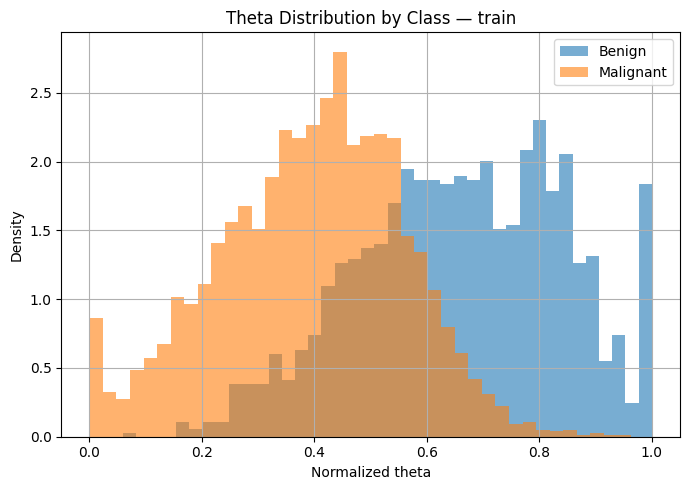

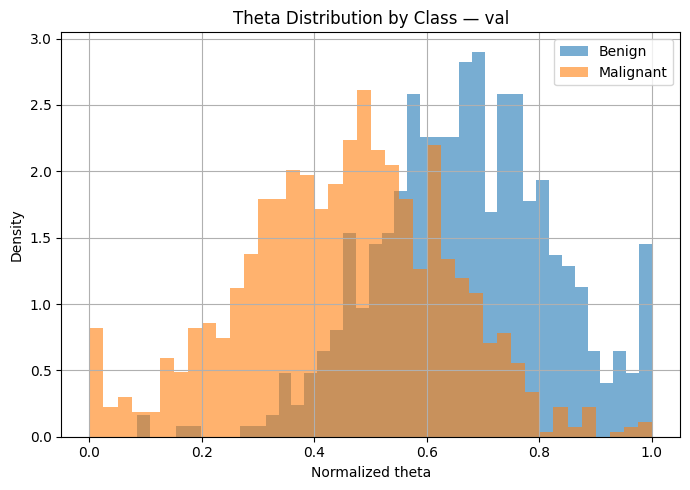

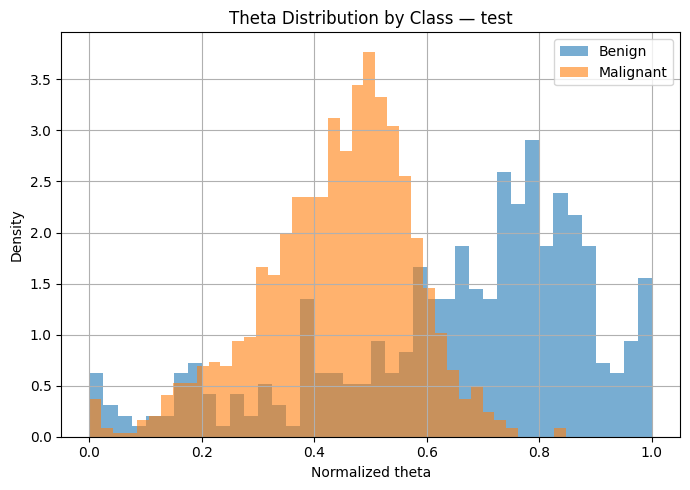

In [18]:
# ============================================================
# 14B. VISUALIZATION: NORMALIZED THETA DISTRIBUTION BY CLASS
# ============================================================

for split_name in ["train", "val", "test"]:
    subset = theta_df[theta_df["split"] == split_name]

    plt.figure(figsize=(7, 5))

    plt.hist(
        subset[subset["label"] == 0]["theta_norm"],
        bins=40,
        alpha=0.6,
        label="Benign",
        density=True,
    )

    plt.hist(
        subset[subset["label"] == 1]["theta_norm"],
        bins=40,
        alpha=0.6,
        label="Malignant",
        density=True,
    )

    plt.xlabel("Normalized theta")
    plt.ylabel("Density")
    plt.title(f"Theta Distribution by Class — {split_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"theta_distribution_{split_name}.png", dpi=300)
    plt.show()

## Cell 15 — Classical SVM baselines on $\theta$

This cell trains classical SVM baselines using the same scalar $\theta$ representation. These baselines are required because the thesis intervention compares QSVM against classical SVM under identical preprocessing, splitting, and feature compression.

In [19]:
# ============================================================
# 15. CLASSICAL SVM BASELINES ON THETA
# ============================================================

SVM_SELECTION_METRIC = "mcc"

def split_theta_arrays(theta_df):
    train = theta_df[theta_df["split"] == "train"].copy()
    val = theta_df[theta_df["split"] == "val"].copy()
    test = theta_df[theta_df["split"] == "test"].copy()

    X_train = train[["theta_norm"]].values
    y_train = train["label"].values

    X_val = val[["theta_norm"]].values
    y_val = val["label"].values

    X_test = test[["theta_norm"]].values
    y_test = test["label"].values

    return train, val, test, X_train, y_train, X_val, y_val, X_test, y_test


train_embed, val_embed, test_embed, X_train, y_train, X_val, y_val, X_test, y_test = split_theta_arrays(theta_df)


def tune_classical_svm(X_train, y_train, X_val, y_val, kernel_name):
    best = {
        "model": None,
        "params": None,
        "val_metrics": None,
        "val_selection_score": -np.inf,
        "selection_metric": SVM_SELECTION_METRIC,
    }

    if kernel_name == "linear":
        grid = [
            {"C": C, "kernel": "linear"}
            for C in [0.001, 0.01, 0.1, 1, 10, 100, 1000]
        ]

    elif kernel_name == "rbf":
        grid = [
            {"C": C, "gamma": gamma, "kernel": "rbf"}
            for C in [0.001, 0.01, 0.1, 1, 10, 100, 1000]
            for gamma in ["scale", 0.01, 0.1, 1.0, 10.0]
        ]

    else:
        raise ValueError(kernel_name)

    for params in grid:
        model = SVC(
            **params,
            class_weight="balanced",
            probability=False,
        )

        model.fit(X_train, y_train)

        val_pred = model.predict(X_val)
        val_score = model.decision_function(X_val)

        metrics = compute_metrics(y_val, val_pred, val_score)

        if metrics["specificity"] == 0.0 or metrics["recall"] == 0.0:
            continue

        selection_score = metrics[SVM_SELECTION_METRIC]

        if selection_score > best["val_selection_score"]:
            best["model"] = model
            best["params"] = params
            best["val_metrics"] = metrics
            best["val_selection_score"] = selection_score

    if best["model"] is None:
        raise RuntimeError(
            f"No non-degenerate classical SVM model was selected for kernel={kernel_name}."
        )

    return best


classical_results = {}

for kernel_name in ["linear", "rbf"]:
    result = tune_classical_svm(
        X_train,
        y_train,
        X_val,
        y_val,
        kernel_name=kernel_name,
    )

    test_pred = result["model"].predict(X_test)
    test_score = result["model"].decision_function(X_test)
    test_metrics = compute_metrics(y_test, test_pred, test_score)

    classical_results[kernel_name] = {
        "selection_metric": result["selection_metric"],
        "val_selection_score": result["val_selection_score"],
        "params": result["params"],
        "val_metrics": result["val_metrics"],
        "test_metrics": test_metrics,
    }

    print(f"\nClassical SVM kernel: {kernel_name}")
    print("Selection metric:", result["selection_metric"])
    print("Validation selection score:", result["val_selection_score"])
    print("Best params:", result["params"])
    print_metrics("Val ", result["val_metrics"])
    print_metrics("Test", test_metrics)

with open(OUT_DIR / "classical_svm_results.json", "w") as f:
    json.dump(to_jsonable(classical_results), f, indent=2)


Classical SVM kernel: linear
Selection metric: mcc
Validation selection score: 0.4547362218035728
Best params: {'C': 0.1, 'kernel': 'linear'}
Val  | accuracy: 0.7214 | balanced_accuracy: 0.7405 | precision: 0.8704 | recall: 0.6822 | specificity: 0.7989 | f1: 0.7649 | mcc: 0.4547 | auc_roc: 0.8178
Test | accuracy: 0.7735 | balanced_accuracy: 0.7661 | precision: 0.9045 | recall: 0.7809 | specificity: 0.7513 | f1: 0.8382 | mcc: 0.4820 | auc_roc: 0.8038

Classical SVM kernel: rbf
Selection metric: mcc
Validation selection score: 0.46553008277886193
Best params: {'C': 0.001, 'gamma': 10.0, 'kernel': 'rbf'}
Val  | accuracy: 0.7319 | balanced_accuracy: 0.7457 | precision: 0.8678 | recall: 0.7036 | specificity: 0.7878 | f1: 0.7771 | mcc: 0.4655 | auc_roc: 0.8152
Test | accuracy: 0.7968 | balanced_accuracy: 0.7781 | precision: 0.9047 | recall: 0.8153 | specificity: 0.7409 | f1: 0.8577 | mcc: 0.5143 | auc_roc: 0.8166


## Cell 16 — Quantum feature map and statevector-equivalent kernel construction

This cell implements the thesis quantum feature map $U_\phi(\theta)=R_y(\theta\pi/2)H$. The QSVM kernel is the fidelity between quantum states generated from pairs of normalized $\theta$ values. For the full dataset, the kernel is computed analytically because the one-qubit feature map has a closed-form fidelity expression equivalent to noiseless statevector simulation. Qiskit is used to verify the circuit structure and log quantum resources.

In [20]:
# ============================================================
# 16. QUANTUM FEATURE MAP AND KERNEL CONSTRUCTION
# ============================================================

from qiskit.quantum_info import Statevector

def build_qsvm_feature_map(theta_value, measure=False):
    if measure:
        qc = QuantumCircuit(1, 1)
    else:
        qc = QuantumCircuit(1)

    qc.h(0)
    qc.ry(float(theta_value) * np.pi / 2.0, 0)

    if measure:
        qc.measure(0, 0)

    return qc


def quantum_kernel_analytic(theta_a, theta_b):
    theta_a = np.asarray(theta_a, dtype=np.float64).reshape(-1, 1)
    theta_b = np.asarray(theta_b, dtype=np.float64).reshape(1, -1)

    alpha_a = theta_a * np.pi / 2.0
    alpha_b = theta_b * np.pi / 2.0

    return np.cos((alpha_a - alpha_b) / 2.0) ** 2


def quantum_kernel_qiskit_small(theta_values):
    states = []

    for theta in theta_values:
        qc = build_qsvm_feature_map(theta, measure=False)
        states.append(Statevector.from_instruction(qc))

    n = len(states)
    K = np.zeros((n, n), dtype=np.float64)

    for i in range(n):
        for j in range(n):
            overlap = np.vdot(states[i].data, states[j].data)
            K[i, j] = np.abs(overlap) ** 2

    return K


qc = build_qsvm_feature_map(theta_value=0.5, measure=True)
backend = AerSimulator()
tqc = transpile(qc, backend)

raw_gate_counts = dict(qc.count_ops())
raw_depth = qc.depth()

transpiled_gate_counts = dict(tqc.count_ops())
transpiled_depth = tqc.depth()

qsvm_resource_log = {
    "feature_map": "H followed by Ry(theta*pi/2)",
    "kernel_execution_mode": "analytic_statevector_equivalent",
    "qiskit_usage": "circuit verification and resource logging",

    "raw_qubits": qc.num_qubits,
    "raw_depth": raw_depth,
    "raw_gate_counts": raw_gate_counts,

    "transpiled_qubits": tqc.num_qubits,
    "transpiled_depth": transpiled_depth,
    "transpiled_gate_counts": transpiled_gate_counts,

    "backend_for_logging": "AerSimulator",
    "experiment_magnification": EXPERIMENT_MAGNIFICATION,
    "seed": SEED,
}

print(qc)
print(json.dumps(to_jsonable(qsvm_resource_log), indent=2))

with open(OUT_DIR / "qsvm_feature_map_resource_log.json", "w") as f:
    json.dump(to_jsonable(qsvm_resource_log), f, indent=2)

theta_check = np.array([0.0, 0.25, 0.5, 1.0])

K_analytic_check = quantum_kernel_analytic(theta_check, theta_check)
K_qiskit_check = quantum_kernel_qiskit_small(theta_check)

max_difference = np.max(np.abs(K_analytic_check - K_qiskit_check))

print("Max analytic-vs-Qiskit kernel difference:", max_difference)

     ┌───┐┌─────────┐┌─┐
  q: ┤ H ├┤ Ry(π/4) ├┤M├
     └───┘└─────────┘└╥┘
c: 1/═════════════════╩═
                      0 
{
  "feature_map": "H followed by Ry(theta*pi/2)",
  "kernel_execution_mode": "analytic_statevector_equivalent",
  "qiskit_usage": "circuit verification and resource logging",
  "raw_qubits": 1,
  "raw_depth": 3,
  "raw_gate_counts": {
    "h": 1,
    "ry": 1,
    "measure": 1
  },
  "transpiled_qubits": 1,
  "transpiled_depth": 2,
  "transpiled_gate_counts": {
    "u3": 1,
    "measure": 1
  },
  "backend_for_logging": "AerSimulator",
  "experiment_magnification": "all",
  "seed": 42
}
Max analytic-vs-Qiskit kernel difference: 4.440892098500626e-16


## Cell 17 — QSVM training with precomputed quantum kernel

This cell trains the thesis QSVM. The quantum stage produces precomputed kernel matrices, while the SVM margin optimization is performed by a classical solver. Hyperparameter $C$ is selected using validation data only.

In [21]:
# ============================================================
# 17. QSVM TRAINING WITH PRECOMPUTED QUANTUM KERNEL
# ============================================================

QSVM_SELECTION_METRIC = "mcc"

theta_train = train_embed["theta_norm"].values
theta_val = val_embed["theta_norm"].values
theta_test = test_embed["theta_norm"].values

K_train = quantum_kernel_analytic(theta_train, theta_train)
K_val = quantum_kernel_analytic(theta_val, theta_train)
K_test = quantum_kernel_analytic(theta_test, theta_train)

print("K_train shape:", K_train.shape)
print("K_val shape:", K_val.shape)
print("K_test shape:", K_test.shape)

best_qsvm = {
    "model": None,
    "C": None,
    "val_metrics": None,
    "val_selection_score": -np.inf,
    "selection_metric": QSVM_SELECTION_METRIC,
}

for C in [0.001, 0.01, 0.1, 1, 10, 100, 1000]:
    model = SVC(
        kernel="precomputed",
        C=C,
        class_weight="balanced",
        probability=False,
    )

    model.fit(K_train, y_train)

    val_pred = model.predict(K_val)
    val_score = model.decision_function(K_val)

    val_metrics = compute_metrics(y_val, val_pred, val_score)

    print(f"\nC={C}")
    print_metrics("Val", val_metrics)

    if val_metrics["specificity"] == 0.0 or val_metrics["recall"] == 0.0:
        print("Degenerate classifier skipped: predicts only one class.")
        continue

    selection_score = val_metrics[QSVM_SELECTION_METRIC]

    if selection_score > best_qsvm["val_selection_score"]:
        best_qsvm["model"] = model
        best_qsvm["C"] = C
        best_qsvm["val_metrics"] = val_metrics
        best_qsvm["val_selection_score"] = selection_score

if best_qsvm["model"] is None:
    raise RuntimeError("No non-degenerate QSVM model was selected.")

qsvm_test_pred = best_qsvm["model"].predict(K_test)
qsvm_test_score = best_qsvm["model"].decision_function(K_test)

qsvm_test_metrics = compute_metrics(
    y_test,
    qsvm_test_pred,
    qsvm_test_score,
)

print("\nBest QSVM C:", best_qsvm["C"])
print("Selection metric:", best_qsvm["selection_metric"])
print("Validation selection score:", best_qsvm["val_selection_score"])
print_metrics("QSVM Test", qsvm_test_metrics)

qsvm_results = {
    "best_C": best_qsvm["C"],
    "selection_metric": best_qsvm["selection_metric"],
    "val_selection_score": best_qsvm["val_selection_score"],
    "val_metrics": best_qsvm["val_metrics"],
    "test_metrics": qsvm_test_metrics,
    "kernel": "one_qubit_fidelity_kernel",
    "feature_map": "H -> Ry(theta*pi/2)",
    "theta_scaler": theta_scaler,
}

with open(OUT_DIR / "qsvm_results.json", "w") as f:
    json.dump(to_jsonable(qsvm_results), f, indent=2)

qsvm_pred_df = test_embed.copy()
qsvm_pred_df["y_true"] = y_test
qsvm_pred_df["y_pred"] = qsvm_test_pred
qsvm_pred_df["y_score"] = qsvm_test_score

qsvm_pred_df.to_csv(OUT_DIR / "qsvm_test_predictions.csv", index=False)

print("Saved:", OUT_DIR / "qsvm_test_predictions.csv")

K_train shape: (4744, 4744)
K_val shape: (1615, 4744)
K_test shape: (1550, 4744)

C=0.001
Val | accuracy: 0.6644 | balanced_accuracy: 0.5000 | precision: 0.6644 | recall: 1.0000 | specificity: 0.0000 | f1: 0.7984 | mcc: 0.0000 | auc_roc: 0.8178
Degenerate classifier skipped: predicts only one class.

C=0.01
Val | accuracy: 0.7183 | balanced_accuracy: 0.7391 | precision: 0.8714 | recall: 0.6757 | specificity: 0.8026 | f1: 0.7612 | mcc: 0.4519 | auc_roc: 0.8178

C=0.1
Val | accuracy: 0.7232 | balanced_accuracy: 0.7419 | precision: 0.8709 | recall: 0.6850 | specificity: 0.7989 | f1: 0.7668 | mcc: 0.4575 | auc_roc: 0.8178

C=1
Val | accuracy: 0.7313 | balanced_accuracy: 0.7439 | precision: 0.8651 | recall: 0.7055 | specificity: 0.7823 | f1: 0.7772 | mcc: 0.4623 | auc_roc: 0.8178

C=10
Val | accuracy: 0.7319 | balanced_accuracy: 0.7366 | precision: 0.8516 | recall: 0.7223 | specificity: 0.7509 | f1: 0.7816 | mcc: 0.4505 | auc_roc: 0.8173

C=100
Val | accuracy: 0.7331 | balanced_accuracy: 0.

## Cell 18 — QSVM evaluation, ROC curve, and patient-level recognition

This cell evaluates the QSVM using image-level diagnostic metrics, ROC-AUC, and patient-level aggregation. Patient-level recognition follows the BreaKHis-style score based on correctly classified images per patient/case.

Image-level QSVM metrics:
Test | accuracy: 0.8000 | balanced_accuracy: 0.7803 | precision: 0.9051 | recall: 0.8196 | specificity: 0.7409 | f1: 0.8602 | mcc: 0.5196 | auc_roc: 0.8038

Confusion matrix [benign=0, malignant=1]:
[[286 100]
 [210 954]]

Classification report:
              precision    recall  f1-score   support

      benign       0.58      0.74      0.65       386
   malignant       0.91      0.82      0.86      1164

    accuracy                           0.80      1550
   macro avg       0.74      0.78      0.75      1550
weighted avg       0.82      0.80      0.81      1550



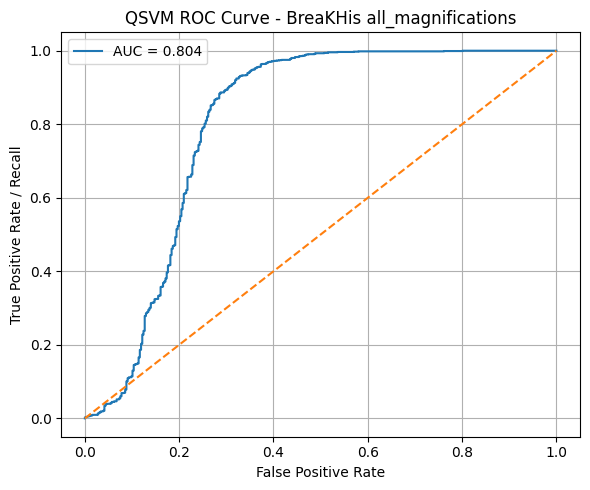


Patient-level recognition rate:
0.7906129329006766

Patient-level score-based metrics:
Patient | accuracy: 0.8824 | balanced_accuracy: 0.8000 | precision: 0.8571 | recall: 1.0000 | specificity: 0.6000 | f1: 0.9231 | mcc: 0.7171 | auc_roc: 0.8000


In [22]:
# ============================================================
# 18. QSVM EVALUATION AND PATIENT-LEVEL RECOGNITION
# ============================================================

def patient_level_recognition(pred_df):
    patient_scores = (
        pred_df.assign(correct=lambda x: (x["y_true"] == x["y_pred"]).astype(int))
               .groupby("patient_id")
               .agg(
                   patient_score=("correct", "mean"),
                   n_images=("correct", "size"),
                   y_true=("y_true", "first"),
                   y_score_mean=("y_score", "mean"),
               )
               .reset_index()
    )

    recognition_rate = patient_scores["patient_score"].mean()

    patient_scores["y_pred_patient"] = (
        patient_scores["y_score_mean"] >= 0.0
    ).astype(int)

    patient_metrics = compute_metrics(
        patient_scores["y_true"].values,
        patient_scores["y_pred_patient"].values,
        patient_scores["y_score_mean"].values,
    )

    return recognition_rate, patient_scores, patient_metrics


print("Image-level QSVM metrics:")
print_metrics("Test", qsvm_test_metrics)

print("\nConfusion matrix [benign=0, malignant=1]:")
print(confusion_matrix(y_test, qsvm_test_pred, labels=[0, 1]))

print("\nClassification report:")
print(
    classification_report(
        y_test,
        qsvm_test_pred,
        target_names=["benign", "malignant"],
        zero_division=0,
    )
)

fpr, tpr, thresholds = roc_curve(y_test, qsvm_test_score)
auc_value = roc_auc_score(y_test, qsvm_test_score)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title(f"QSVM ROC Curve - BreaKHis {experiment_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "qsvm_roc_curve.png", dpi=300)
plt.show()

roc_df = pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "threshold": thresholds,
})

roc_df.to_csv(OUT_DIR / "qsvm_roc_curve.csv", index=False)

patient_recognition_rate, patient_scores_df, patient_metrics = patient_level_recognition(
    qsvm_pred_df
)

print("\nPatient-level recognition rate:")
print(patient_recognition_rate)

print("\nPatient-level score-based metrics:")
print_metrics("Patient", patient_metrics)

patient_scores_df.to_csv(OUT_DIR / "qsvm_patient_scores.csv", index=False)

with open(OUT_DIR / "qsvm_patient_metrics.json", "w") as f:
    json.dump(
        to_jsonable({
            "patient_recognition_rate": patient_recognition_rate,
            "patient_metrics": patient_metrics,
        }),
        f,
        indent=2,
    )

## Cell 18B — Visualize QSVM confusion matrix

This cell plots and saves the QSVM confusion matrix for the held-out test split.

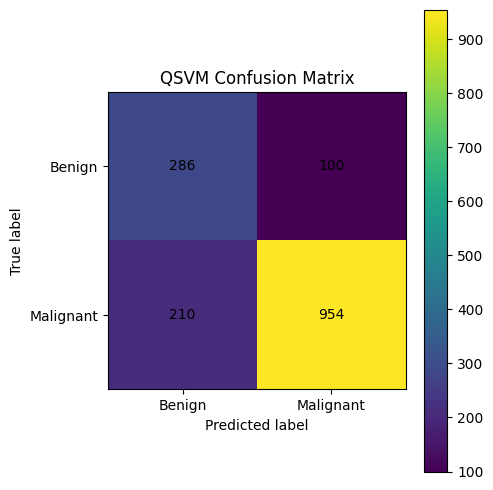

In [23]:
# ============================================================
# 18B. VISUALIZATION: QSVM CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, qsvm_test_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Benign", "Malignant"])
ax.set_yticklabels(["Benign", "Malignant"])

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("QSVM Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(OUT_DIR / "qsvm_confusion_matrix.png", dpi=300)
plt.show()

## Cell 18C — Compare classical SVM and QSVM metrics

This cell compares the final test metrics of the classical SVM baselines and the QSVM.

,model,accuracy,balanced_accuracy,precision,recall,specificity,f1,mcc,auc_roc
0,Classical SVM (linear),0.773548,0.766112,0.904478,0.780928,0.751295,0.838174,0.482040,0.803755
1,Classical SVM (rbf),0.796774,0.778112,0.904671,0.815292,0.740933,0.857659,0.514297,0.816606
2,QSVM,0.800000,0.780260,0.905123,0.819588,0.740933,0.860234,0.519637,0.803793


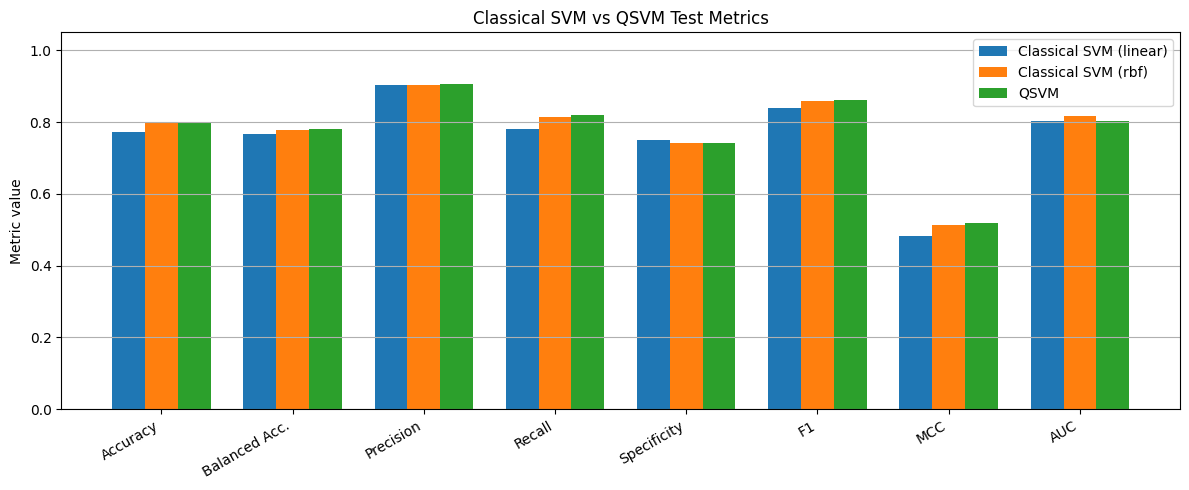

In [24]:
# ============================================================
# 18C. VISUALIZATION: CLASSICAL SVM VS QSVM METRIC COMPARISON
# ============================================================

comparison_rows = []

for model_name, result in classical_results.items():
    row = {"model": f"Classical SVM ({model_name})"}
    row.update(result["test_metrics"])
    comparison_rows.append(row)

qsvm_row = {"model": "QSVM"}
qsvm_row.update(qsvm_test_metrics)
comparison_rows.append(qsvm_row)

comparison_df = pd.DataFrame(comparison_rows)

metrics_to_plot = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "specificity",
    "f1",
    "mcc",
    "auc_roc",
]

display(comparison_df[["model"] + metrics_to_plot])

x = np.arange(len(metrics_to_plot))
width = 0.25

plt.figure(figsize=(12, 5))

for i, row in comparison_df.iterrows():
    plt.bar(
        x + i * width,
        [row[m] for m in metrics_to_plot],
        width=width,
        label=row["model"],
    )

plt.xticks(
    x + width,
    [
        "Accuracy",
        "Balanced Acc.",
        "Precision",
        "Recall",
        "Specificity",
        "F1",
        "MCC",
        "AUC",
    ],
    rotation=30,
    ha="right",
)

plt.ylim(0, 1.05)
plt.ylabel("Metric value")
plt.title("Classical SVM vs QSVM Test Metrics")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(OUT_DIR / "svm_vs_qsvm_metric_comparison.png", dpi=300)
plt.show()

## Cell 18D — Visualize patient-level QSVM decision scores

This cell plots patient-level mean QSVM decision scores. The horizontal line marks the SVM decision threshold.

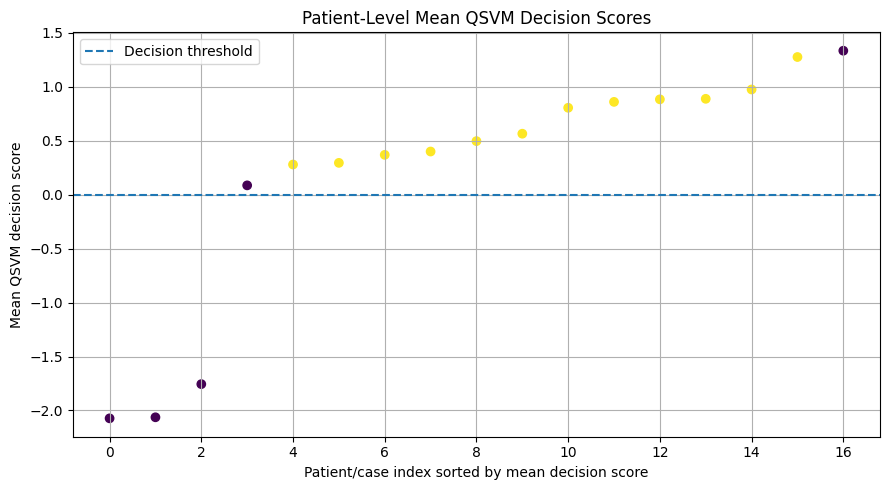

,patient_id,n_images,y_true,y_score_mean,patient_score,y_pred_patient
0,14-21978AB,65,0,-2.072695,0.984615,0
1,14-23222AB,68,0,-2.062905,1.000000,0
2,14-21998EF,121,0,-1.755584,0.950413,0
3,14-19854C,64,0,0.086171,0.531250,1
4,14-15704,127,1,0.279364,0.661417,1
5,14-16448,53,1,0.294572,0.660377,1
6,14-15570C,125,1,0.368854,0.792000,1
7,14-12773,90,1,0.399741,0.711111,1
8,14-9146,90,1,0.496161,0.700000,1
9,14-16456,178,1,0.564795,0.842697,1


In [25]:
# ============================================================
# 18D. VISUALIZATION: PATIENT-LEVEL QSVM DECISION SCORES
# ============================================================

plot_df = patient_scores_df.sort_values("y_score_mean").reset_index(drop=True)

plt.figure(figsize=(9, 5))
plt.axhline(0.0, linestyle="--", label="Decision threshold")

plt.scatter(
    range(len(plot_df)),
    plot_df["y_score_mean"],
    c=plot_df["y_true"],
)

plt.xlabel("Patient/case index sorted by mean decision score")
plt.ylabel("Mean QSVM decision score")
plt.title("Patient-Level Mean QSVM Decision Scores")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "patient_level_qsvm_scores.png", dpi=300)
plt.show()

display(
    plot_df[
        [
            "patient_id",
            "n_images",
            "y_true",
            "y_score_mean",
            "patient_score",
            "y_pred_patient",
        ]
    ]
)

## Final simulator result interpretation

The main QSVM experiment uses an analytic one-qubit fidelity kernel equivalent to noiseless statevector simulation. IBM Quantum hardware execution was not performed in this run and is logged as disabled. The result should therefore be interpreted as a simulator-equivalent QSVM experiment, not as a hardware QPU result.

The QSVM achieved the most balanced performance among the scalar-$\theta$ SVM variants, with the highest balanced accuracy, F1-score, and MCC. The improvement over the classical SVM baselines is modest, so the result supports feasibility and reproducibility of the proposed QSVM diagnostic workflow rather than quantum advantage.

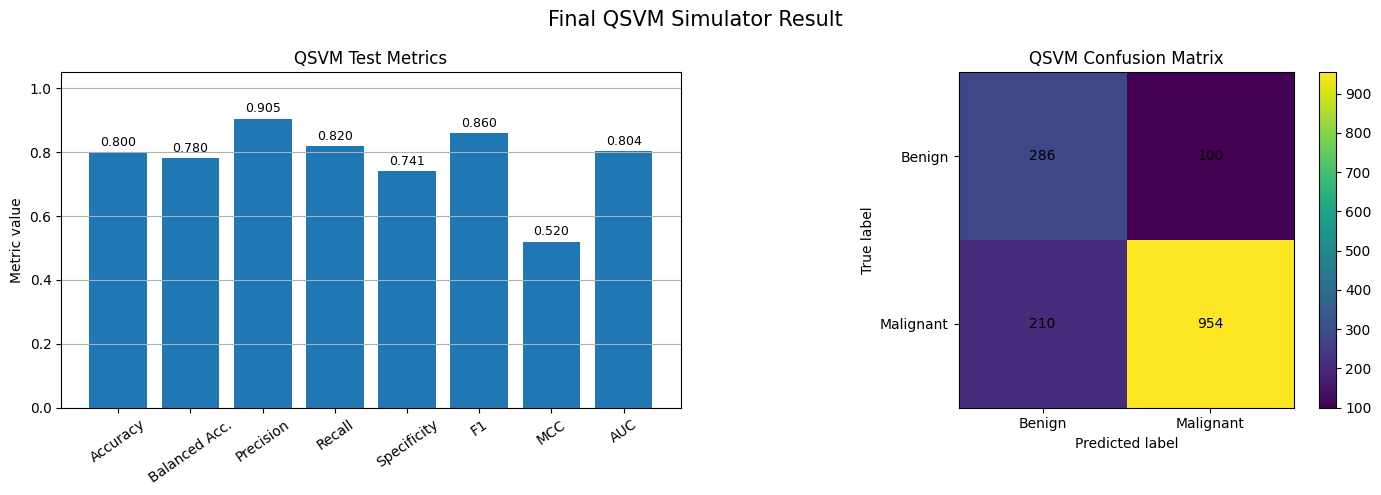

In [26]:
# ============================================================
# 18E. VISUALIZATION: FINAL QSVM SUMMARY DASHBOARD
# ============================================================

summary_metrics = {
    "Accuracy": qsvm_test_metrics["accuracy"],
    "Balanced Acc.": qsvm_test_metrics["balanced_accuracy"],
    "Precision": qsvm_test_metrics["precision"],
    "Recall": qsvm_test_metrics["recall"],
    "Specificity": qsvm_test_metrics["specificity"],
    "F1": qsvm_test_metrics["f1"],
    "MCC": qsvm_test_metrics["mcc"],
    "AUC": qsvm_test_metrics["auc_roc"],
}

cm = confusion_matrix(y_test, qsvm_test_pred, labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metric bar chart.
metric_names = list(summary_metrics.keys())
metric_values = list(summary_metrics.values())

axes[0].bar(metric_names, metric_values)
axes[0].set_title("QSVM Test Metrics")
axes[0].set_ylabel("Metric value")
axes[0].set_ylim(0.0, 1.05)
axes[0].tick_params(axis="x", rotation=35)
axes[0].grid(axis="y")

for i, value in enumerate(metric_values):
    axes[0].text(i, value + 0.02, f"{value:.3f}", ha="center", fontsize=9)

# Confusion matrix.
im = axes[1].imshow(cm)
axes[1].set_title("QSVM Confusion Matrix")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Benign", "Malignant"])
axes[1].set_yticklabels(["Benign", "Malignant"])
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1].text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

fig.suptitle(
    "Final QSVM Simulator Result",
    fontsize=15,
)

plt.tight_layout()
plt.savefig(OUT_DIR / "final_qsvm_summary_dashboard.png", dpi=300)
plt.show()

## Cell 19 — Optional IBM Quantum hardware subset

This cell is disabled by default. Use it only after the simulator pipeline is complete. Because kernel estimation scales quadratically, hardware execution should be restricted to a small balanced subset and reported as feasibility evidence.

In [27]:
# ============================================================
# 19. OPTIONAL IBM QUANTUM HARDWARE SUBSET
# ============================================================

RUN_IBM_HARDWARE = False

hardware_execution_log = {
    "hardware_executed": False,
    "reason": (
        "IBM Quantum hardware execution was not run in this experiment. "
        "The main QSVM result uses an analytic statevector-equivalent "
        "one-qubit quantum fidelity kernel."
    ),
}

if RUN_IBM_HARDWARE:
    from qiskit_ibm_runtime import QiskitRuntimeService
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    service = QiskitRuntimeService(channel="ibm_quantum")

    backend = service.least_busy(
        operational=True,
        simulator=False,
    )

    print("Selected backend:", backend.name)

    subset_per_class = 10

    hw_subset = (
        train_embed.groupby("label", group_keys=False)
                   .apply(
                       lambda x: x.sample(
                           n=min(subset_per_class, len(x)),
                           random_state=SEED,
                       )
                   )
                   .reset_index(drop=True)
    )

    theta_hw = hw_subset["theta_norm"].values

    circuits = [
        build_qsvm_feature_map(theta, measure=True)
        for theta in theta_hw
    ]

    pass_manager = generate_preset_pass_manager(
        backend=backend,
        optimization_level=1,
    )

    transpiled_circuits = [
        pass_manager.run(circuit)
        for circuit in circuits
    ]

    hardware_execution_log = {
        "hardware_executed": True,
        "backend": backend.name,
        "n_circuits": len(transpiled_circuits),
        "shots": 1024,
        "depths": [circuit.depth() for circuit in transpiled_circuits],
        "gate_counts": [dict(circuit.count_ops()) for circuit in transpiled_circuits],
        "seed": SEED,
        "experiment_magnification": EXPERIMENT_MAGNIFICATION,
        "note": (
            "This is a small hardware feasibility/resource subset, "
            "not a full hardware QSVM kernel evaluation."
        ),
    }

    with open(OUT_DIR / "ibm_hardware_execution_log.json", "w") as f:
        json.dump(to_jsonable(hardware_execution_log), f, indent=2)

    print(json.dumps(to_jsonable(hardware_execution_log), indent=2))

else:
    print("IBM hardware execution is disabled.")
    print(json.dumps(to_jsonable(hardware_execution_log), indent=2))

    with open(OUT_DIR / "ibm_hardware_execution_log.json", "w") as f:
        json.dump(to_jsonable(hardware_execution_log), f, indent=2)

IBM hardware execution is disabled.
{
  "hardware_executed": false,
  "reason": "IBM Quantum hardware execution was not run in this experiment. The main QSVM result uses an analytic statevector-equivalent one-qubit quantum fidelity kernel."
}


## Cell 20 — Runtime checks and debugging summary

This cell verifies that the main artifacts were created and prints a compact debugging summary. Run this before the runtime manifest to catch missing files or failed stages.

In [28]:
# ============================================================
# 20. RUNTIME CHECKS AND DEBUGGING SUMMARY
# ============================================================

required_files = [
    OUT_DIR / "metadata_split.csv",
    OUT_DIR / "best_theta_extractor.pt",
    OUT_DIR / "theta_raw_embeddings.csv",
    OUT_DIR / "theta_embeddings_normalized.csv",
    OUT_DIR / "theta_scaler.json",
    OUT_DIR / "classical_svm_results.json",
    OUT_DIR / "qsvm_feature_map_resource_log.json",
    OUT_DIR / "qsvm_results.json",
    OUT_DIR / "qsvm_test_predictions.csv",
    OUT_DIR / "qsvm_patient_scores.csv",
]

missing_files = [str(path) for path in required_files if not path.exists()]

if missing_files:
    print("Missing required files:")
    for path in missing_files:
        print(path)
else:
    print("All required artifacts are present.")

debug_summary = {
    "experiment_name": experiment_name,
    "experiment_magnification": EXPERIMENT_MAGNIFICATION,
    "output_directory": str(OUT_DIR),
    "device": str(DEVICE),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "images_total_experiment": int(len(df_exp)),
    "train_images": int(len(train_df)),
    "val_images": int(len(val_df)),
    "test_images": int(len(test_df)),
    "train_patients": int(train_df["patient_id"].nunique()),
    "val_patients": int(val_df["patient_id"].nunique()),
    "test_patients": int(test_df["patient_id"].nunique()),
    "theta_rows": int(len(theta_df)),
    "qsvm_best_C": best_qsvm["C"],
    "qsvm_test_metrics": qsvm_test_metrics,
    "patient_recognition_rate": patient_recognition_rate,
}

print(json.dumps(to_jsonable(debug_summary), indent=2))

with open(OUT_DIR / "debug_summary.json", "w") as f:
    json.dump(to_jsonable(debug_summary), f, indent=2)

All required artifacts are present.
{
  "experiment_name": "all_magnifications",
  "experiment_magnification": "all",
  "output_directory": "C:\\Users\\Matheus Teixeira\\Documents\\University\\Master\\Thesis\\Diagnostic Intervention\\outputs\\thesis_qsvm_breakhis_all_magnifications",
  "device": "cuda",
  "gpu": "NVIDIA GeForce RTX 4070 Ti",
  "images_total_experiment": 7909,
  "train_images": 4744,
  "val_images": 1615,
  "test_images": 1550,
  "train_patients": 48,
  "val_patients": 16,
  "test_patients": 17,
  "theta_rows": 7909,
  "qsvm_best_C": 1,
  "qsvm_test_metrics": {
    "accuracy": 0.8,
    "precision": 0.905123339658444,
    "recall": 0.8195876288659794,
    "f1": 0.8602344454463481,
    "mcc": 0.5196373058028718,
    "specificity": 0.7409326424870466,
    "balanced_accuracy": 0.780260135676513,
    "tn": 286,
    "fp": 100,
    "fn": 210,
    "tp": 954,
    "auc_roc": 0.8037932001495647
  },
  "patient_recognition_rate": 0.7906129329006766
}


## Cell 21 — Runtime manifest

This cell saves the full runtime configuration, package versions, dataset split counts, hardware information, seeds, model settings, and quantum resource information. This manifest supports reproducibility and thesis reporting.

In [29]:
# ============================================================
# 21. RUNTIME MANIFEST
# ============================================================

def get_pip_freeze():
    try:
        return subprocess.check_output(
            [sys.executable, "-m", "pip", "freeze"],
            text=True,
        ).splitlines()
    except Exception:
        return []

manifest = {
    "timestamp_utc": datetime.utcnow().isoformat() + "Z",
    "seed": SEED,
    "device": str(DEVICE),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "python": platform.python_version(),
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "qiskit": qiskit.__version__,
    "qiskit_aer": qiskit_aer.__version__,
    "experiment_name": experiment_name,
    "experiment_magnification": EXPERIMENT_MAGNIFICATION,
    "backbone": BACKBONE,
    "freeze_backbone": FREEZE_BACKBONE,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LR,
    "train_frac": TRAIN_FRAC,
    "val_frac": VAL_FRAC,
    "test_frac": TEST_FRAC,
    "project_root": str(PROJECT_ROOT),
    "breast_root": str(BREAST_ROOT),
    "output_directory": str(OUT_DIR),
    "class_counts_train": train_df["label_name"].value_counts().to_dict(),
    "class_counts_val": val_df["label_name"].value_counts().to_dict(),
    "class_counts_test": test_df["label_name"].value_counts().to_dict(),
    "patient_counts": {
        "train": train_df["patient_id"].nunique(),
        "val": val_df["patient_id"].nunique(),
        "test": test_df["patient_id"].nunique(),
    },
    "image_counts": {
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df),
    },
    "theta_scaler": theta_scaler,
    "classical_svm_results": classical_results,
    "qsvm_resource_log": qsvm_resource_log,
    "qsvm_results": qsvm_results,
    "hardware_execution_log": hardware_execution_log,
    "patient_recognition_rate": patient_recognition_rate,
    "patient_metrics": patient_metrics,
    "pip_freeze": get_pip_freeze(),
}

with open(OUT_DIR / "runtime_manifest.json", "w") as f:
    json.dump(to_jsonable(manifest), f, indent=2)

print("Saved runtime manifest:")
print(OUT_DIR / "runtime_manifest.json")

Saved runtime manifest:
C:\Users\Matheus Teixeira\Documents\University\Master\Thesis\Diagnostic Intervention\outputs\thesis_qsvm_breakhis_all_magnifications\runtime_manifest.json
